# Jupyter Notebook_José Otavio

In [2]:
!pip install xlrd

In [10]:
import matplotlib.pyplot as plt

In [11]:
import pandas as pd

In [35]:
import numpy as np

In [12]:
df = pd.read_excel(r'C:\Users\User\Documents\default_of_credit_card_clients__courseware_version_1_21_19.xls')

In [23]:
print(df.columns)

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')


# Exercício 1

Crie listas com nomes para as características financeiras restantes.

In [24]:
bill_features = [
    'BILL_AMT1',
    'BILL_AMT2',
    'BILL_AMT3',
    'BILL_AMT4',
    'BILL_AMT5',
    'BILL_AMT6'
]

pay_features = [
    'PAY_AMT1',
    'PAY_AMT2',
    'PAY_AMT3',
    'PAY_AMT4',
    'PAY_AMT5',
    'PAY_AMT6'
]

# Exercício 2

Use .describe() para examinar as sínteses estatísticas das características de valor da fatura. Reflita sobre o que viu. Faz sentido?

In [25]:
df[bill_features].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,50646.744233,48624.349167,4.649736e+04,42791.362167,39884.398167,38480.350933
std,73376.695080,70893.963498,6.910251e+04,64090.316188,60606.644833,59406.836932
min,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000
25%,3234.000000,2682.000000,2.403000e+03,2034.000000,1534.000000,1080.000000
50%,21644.500000,20597.000000,1.975250e+04,18759.500000,17835.500000,16643.000000
75%,66148.500000,62999.750000,5.952675e+04,53572.250000,49804.000000,48863.500000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


Os resultados mostrados fazem sentido porque:
* Existem valores muito altos de faturas; 
* Alguns clientes possuem dívidas que podem ser muito maiores que os outros;
* Presença de dispersão elevada nos dados;

# Exercício 3

Visualize as características de valor da fatura usando uma grade 2 por 3 de plotagens de histograma. Dica: Você pode usar 20 bins para essa visualização.

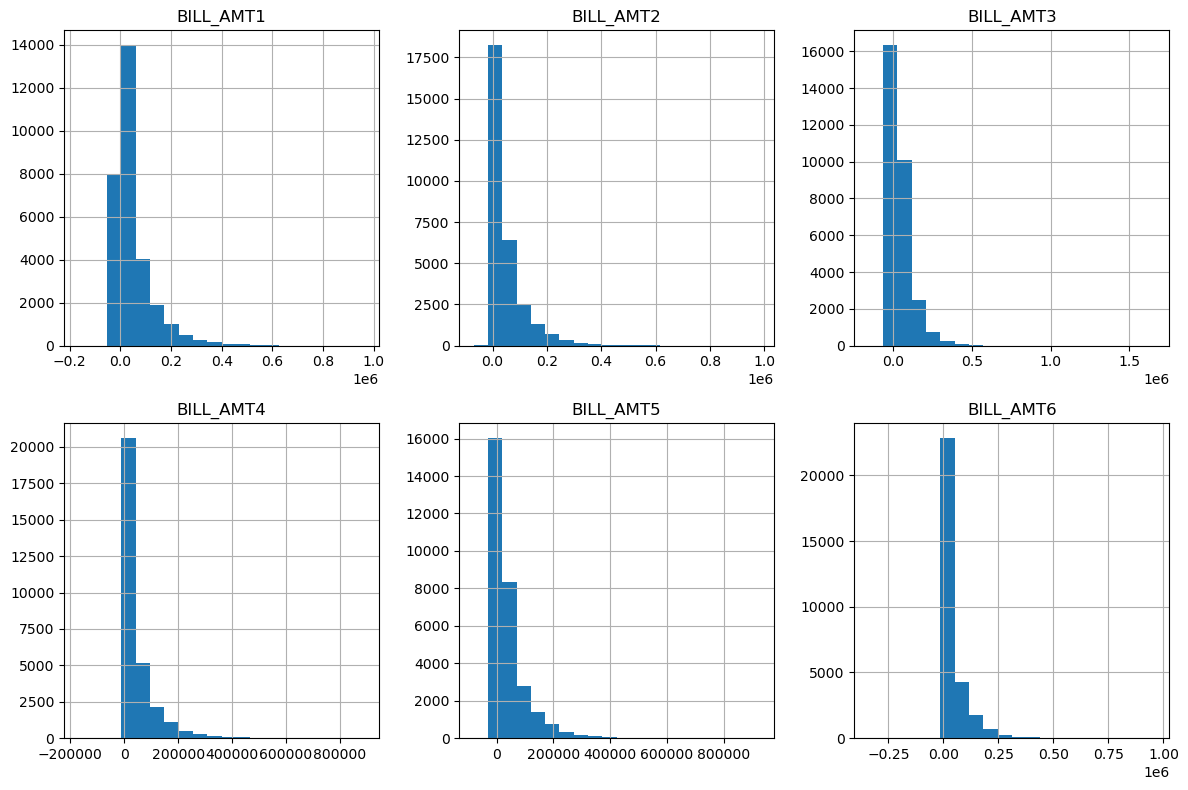

In [26]:
df[bill_features].hist(
    bins=20,
    layout=(2,3),
    figsize=(12,8)
)

plt.tight_layout()
plt.show()

# Exercício 4

Obtenha o resumo de .describe() para as características de valor do pagamento. Faz sentido?

In [27]:
df[pay_features].describe()

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000
mean,5613.321500,5.855410e+03,5174.387967,4776.089733,4754.749200,5164.223267
std,16539.094312,2.299256e+04,17565.538305,15532.893047,15239.070708,17712.664703
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,836.000000,7.217500e+02,371.000000,223.000000,170.750000,9.000000
50%,2084.500000,2.000000e+03,1776.000000,1500.000000,1500.000000,1500.000000
75%,5000.000000,5.000000e+03,4500.000000,4000.000000,4000.000000,4000.000000
max,873552.000000,1.684259e+06,896040.000000,621000.000000,426529.000000,528666.000000


Mais uma vez os resultados fazem sentido, pois:
* Muitos pagamentos são baixos ou iguais a zero;
* Há alguns pagamentos extremamente altos;
* Dados com forte assimetria;

# Exercício 5

Plote um histograma das características de pagamento da fatura semelhante ao das características de valor da fatura, mas aplique também alguma rotação aos rótulos do eixo x com o argumento de palavra-chave xrot para que eles não se sobreponham. Podemos incluir o argumento de palavra-chave xrot=<ângulo> em qualquer função de plotagem para girar os rótulos do eixo x de acordo com um ângulo específico em graus. Considere os resultados.

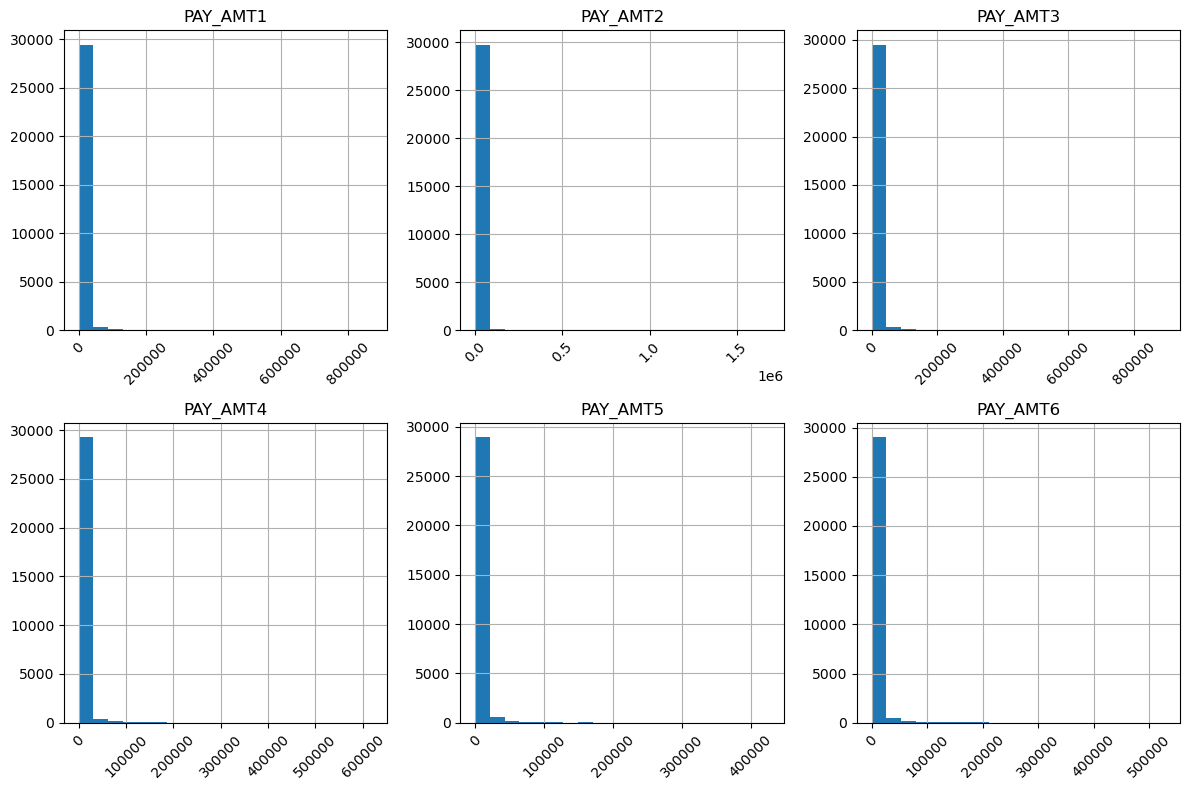

In [29]:
df[pay_features].hist(
    bins=20,
    layout=(2,3),
    figsize=(12,8),
    xrot=45
)

plt.tight_layout()
plt.show()

Os histogramas mostram:

* Muitos pagamentos próximos de zero;
* Concentração elevada nos menores valores;
* Poucos pagamentos muito altos.

# Exercício 6

Use uma máscara booleana para ver quantos dos dados de valor do pagamento são exatamente iguais a 0. O resultado faz sentido dado o histograma da etapa anterior?

In [30]:
pay_zero_mask = df[pay_features] == 0

In [31]:
pay_zero_mask.sum()

PAY_AMT1    5504
PAY_AMT2    5663
PAY_AMT3    6223
PAY_AMT4    6660
PAY_AMT5    6955
PAY_AMT6    7416
dtype: int64

o resultado faz sentido:

* Os histogramas mostraram concentração muito grande próxima de zero;
* Muitos clientes não realizaram pagamentos em determinados meses.

# Exercício 7

Ignorando os pagamentos iguais a 0 usando a máscara que criou na etapa anterior, utilize o método .apply() do pandas e o método np.log10() do NumPy para plotar histogramas de transformações logarítmicas dos pagamentos diferentes de zero. Considere os resultados. Dica: Você pode usar .apply() para aplicar qualquer função, inclusive log10, a todos os elementos de um DataFrame ou de uma coluna usando a sintaxe a seguir: .apply(<nome_função>).

In [32]:
pay_non_zero = df[pay_features][df[pay_features] > 0]

In [36]:
log_payments = pay_non_zero.apply(np.log10)

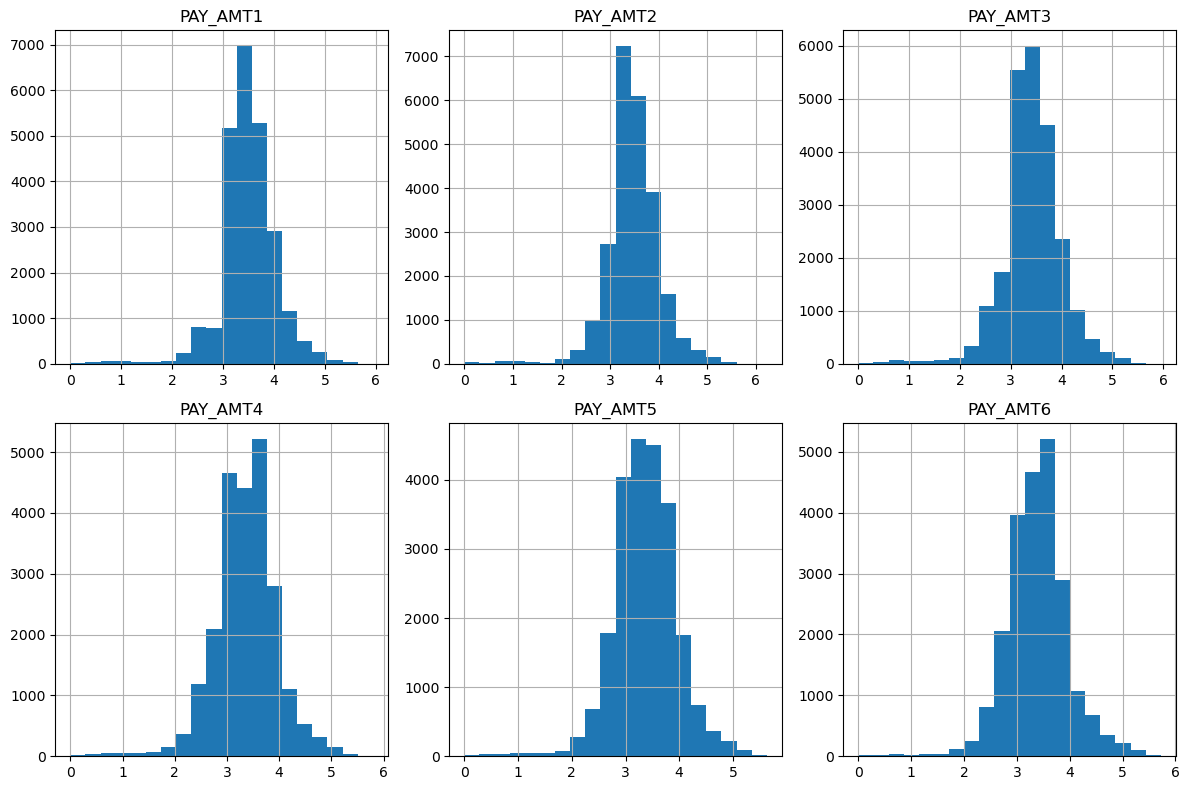

In [37]:
log_payments.hist(
    bins=20,
    layout=(2,3),
    figsize=(12,8)
)

plt.tight_layout()
plt.show()